TF: 2.20.0
Image 1
0.5


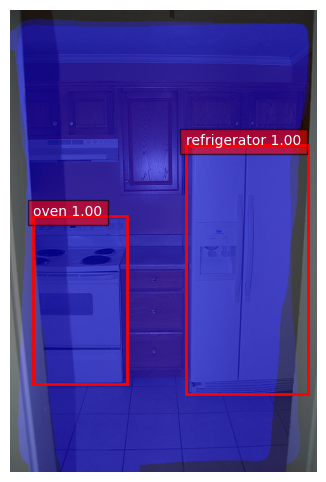

0.3


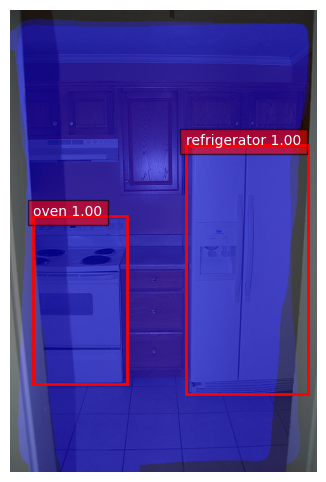

Image 2
0.5


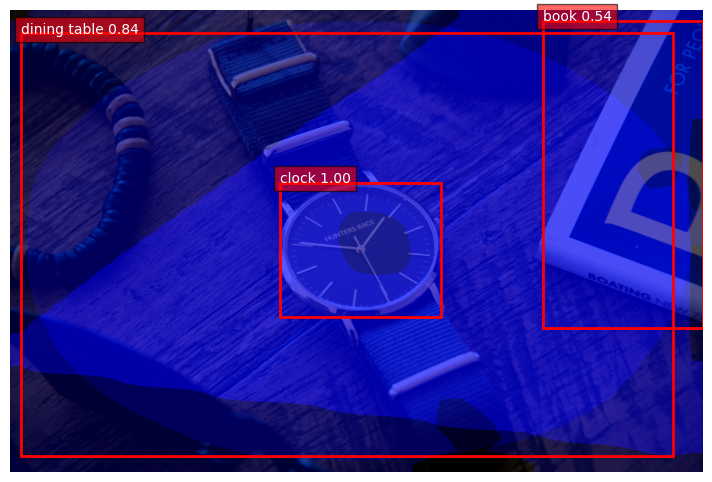

0.3


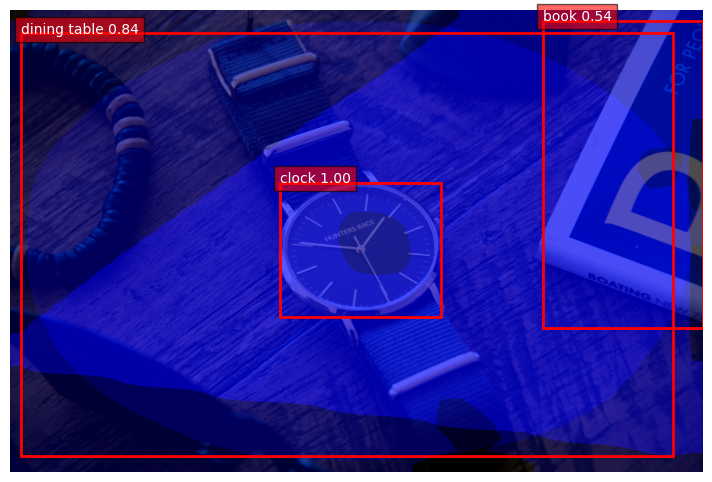

Image 3
0.5


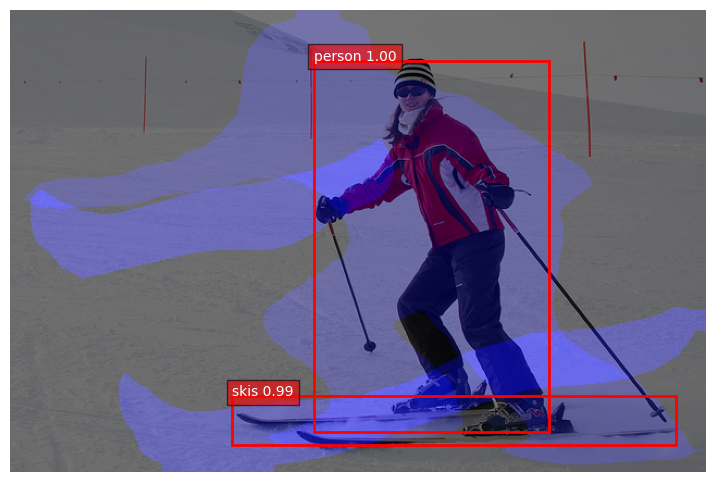

0.3


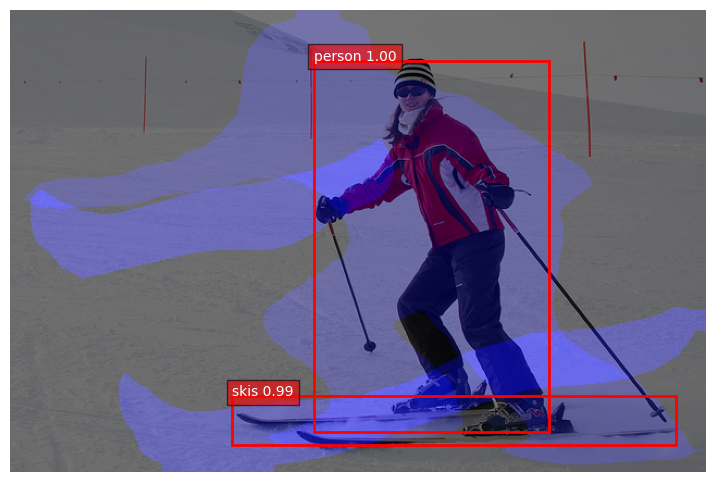

Image 4
0.5


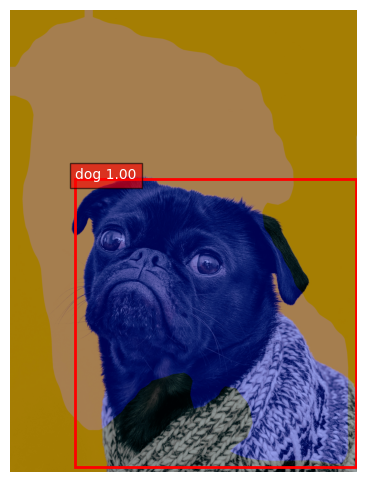

0.3


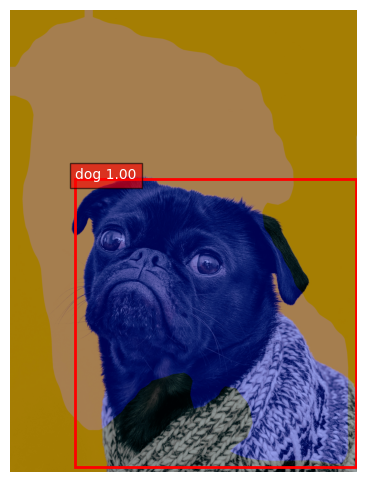

Image 5
0.5


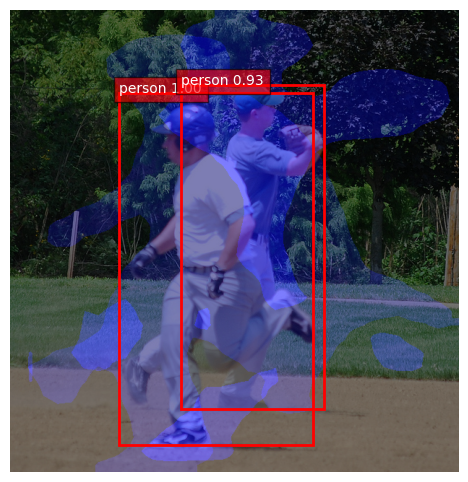

0.3


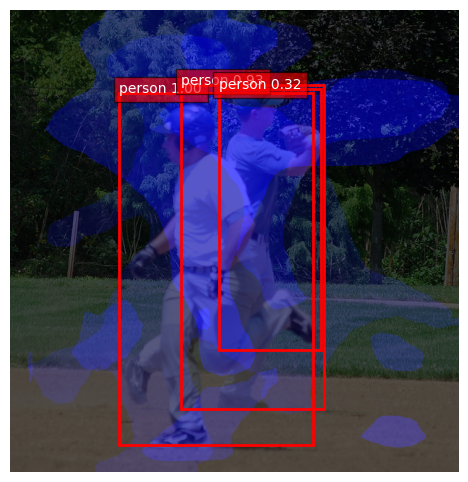

In [5]:
import cv2
!pip install -q tensorflow tensorflow-hub matplotlib opencv-python pillow requests

import numpy as np
import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import requests
from io import BytesIO

print("TF:", tf.__version__)

model_url = "https://tfhub.dev/tensorflow/mask_rcnn/inception_resnet_v2_1024x1024/1"
model = hub.load(model_url)

labels_map = {
    1:"person",2:"bicycle",3:"car",4:"motorcycle",5:"airplane",6:"bus",7:"train",
    8:"truck",9:"boat",10:"traffic light",11:"fire hydrant",13:"stop sign",
    14:"parking meter",15:"bench",16:"bird",17:"cat",18:"dog",19:"horse",
    20:"sheep",21:"cow",22:"elephant",23:"bear",24:"zebra",25:"giraffe",
    27:"backpack",28:"umbrella",31:"handbag",32:"tie",33:"suitcase",
    34:"frisbee",35:"skis",36:"snowboard",37:"sports ball",38:"kite",
    39:"baseball bat",40:"baseball glove",41:"skateboard",42:"surfboard",
    43:"tennis racket",44:"bottle",46:"wine glass",47:"cup",48:"fork",
    49:"knife",50:"spoon",51:"bowl",52:"banana",53:"apple",54:"sandwich",
    55:"orange",56:"broccoli",57:"carrot",58:"hot dog",59:"pizza",
    60:"donut",61:"cake",62:"chair",63:"couch",64:"potted plant",
    65:"bed",67:"dining table",70:"toilet",72:"tv",73:"laptop",
    74:"mouse",75:"remote",76:"keyboard",77:"cell phone",78:"microwave",
    79:"oven",80:"toaster",81:"sink",82:"refrigerator",84:"book",
    85:"clock",86:"vase",87:"scissors",88:"teddy bear",89:"hair drier",
    90:"toothbrush"
}

def get_img(url):
    r = requests.get(url)
    img = Image.open(BytesIO(r.content)).convert("RGB")
    return np.array(img)

urls = [
    "http://images.cocodataset.org/val2017/000000000802.jpg",
    "https://images.unsplash.com/photo-1508057198894-247b23fe5ade",
    "http://images.cocodataset.org/val2017/000000000785.jpg",
    "https://images.unsplash.com/photo-1517849845537-4d257902454a",
    "http://images.cocodataset.org/val2017/000000000872.jpg"
]

imgs = [get_img(u) for u in urls]

def predict(img):
    t = tf.convert_to_tensor(img, dtype=tf.uint8)
    t = tf.expand_dims(t, 0)
    out = model(t)
    return {k: v.numpy() for k,v in out.items()}

def draw(img, out, th=0.5):
    vis = img.copy()
    h,w,_ = vis.shape

    b = out["detection_boxes"][0]
    c = out["detection_classes"][0].astype(int)
    s = out["detection_scores"][0]
    m = out["detection_masks"][0]

    idx = s >= th

    b = b[idx]
    c = c[idx]
    s = s[idx]
    m = m[idx]

    fig, ax = plt.subplots(1, figsize=(10,6))
    ax.imshow(vis)

    for i in range(len(b)):
        y1,x1,y2,x2 = b[i]
        x1,y1 = int(x1*w), int(y1*h)
        x2,y2 = int(x2*w), int(y2*h)

        rect = patches.Rectangle((x1,y1), x2-x1, y2-y1,
                                 linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)

        name = labels_map.get(c[i], "obj")
        ax.text(x1, y1, f"{name} {s[i]:.2f}",
                color='white', bbox=dict(facecolor='red', alpha=0.6))

        mask = cv2.resize(m[i], (w,h))
        mask = mask > 0.5

        overlay = np.zeros_like(vis)
        overlay[:,:,2] = mask * 255

        ax.imshow(overlay, alpha=0.3)

    ax.axis("off")
    plt.show()
for i, img in enumerate(imgs):
    print("="*40)
    print(f"Image {i+1}")

    out = predict(img)

    print("0.5")
    draw(img, out, 0.5)

    print("0.3")
    draw(img, out, 0.3)